In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [8]:
ds=pd.read_csv("anaconda_projects/Salary_Data.csv")

In [10]:
X=ds["YearsExperience"].values
Y=ds["Salary"].values

In [11]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [12]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

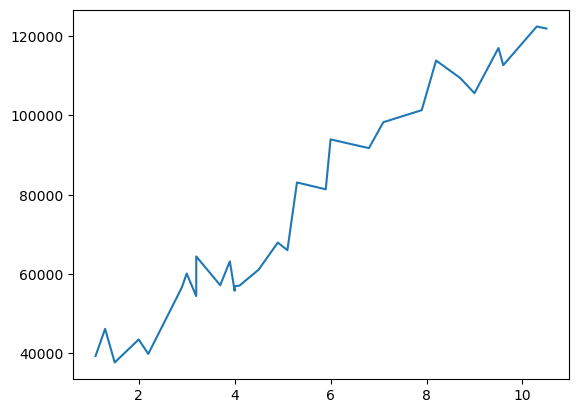

In [13]:
plt.plot(X,Y)

In [14]:
X=np.array(X)
Y=np.array(Y)

In [15]:
def mean(X):
    return np.sum(X)/len(X)

In [16]:
def variance(X):
    mean_value=mean(X)
    return np.sum((X-mean_value)**2)/len(X)

In [17]:
def norm(X):
    mean_value=mean(X)
    variance_value=variance(X)
    return (X-mean_value)/np.sqrt(variance_value)

In [18]:
X_norm=norm(X)

In [19]:
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

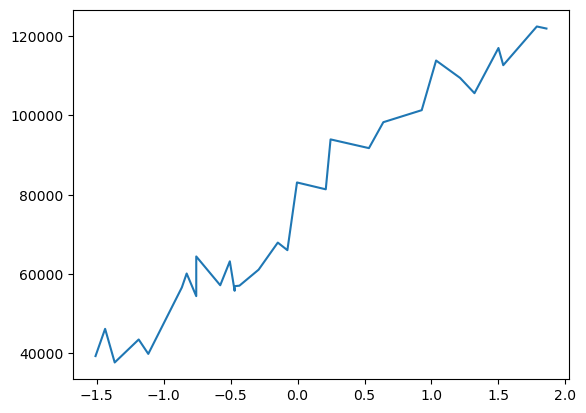

In [20]:
plt.plot(X_norm,Y)

In [32]:
class SimpleLR:
    def __init__(self,lr=0.1,max_iter=2000,threshold=1e-6):
        self.lr=lr
        self.max_iter=max_iter
        self.threshold=threshold
        self.weight=random.uniform(-1,1)
        self.bias=random.uniform(-1,1)
    def predict(self,X):
        return self.weight*X+self.bias
    def fit(self,X,Y):
        n=len(X)
        loss_history=[]
        y_pred=self.predict(X)
        errors=Y-y_pred
        prev_loss=(1/(2*n))*np.sum(errors**2)
        loss_history.append(prev_loss)
        for i in range(self.max_iter):
            w_grad=(1/n)*np.sum(errors*X)
            b_grad=(1/n)*np.sum(errors)
            self.weight+=self.lr*w_grad
            self.bias+=self.lr*b_grad
            y_pred=self.predict(X)
            errors=Y-y_pred
            curr_loss=(1/(2*n))*np.sum(errors**2)
            if np.abs(curr_loss-prev_loss)<self.threshold:
                break
            prev_loss=curr_loss
            loss_history.append(curr_loss)
        return loss_history
    def plot(self,X,Y):
        y_pred=self.predict(X)
        plt.plot(X,Y)
        plt.plot(X,y_pred)

In [34]:
model=SimpleLR()

In [35]:
loss_history=model.fit(X_norm,Y)

In [36]:
loss_history

[np.float64(3251492312.6523776),
 np.float64(2636679513.662043),
 np.float64(2138681146.4798713),
 np.float64(1735302469.062313),
 np.float64(1408565740.3540897),
 np.float64(1143908990.1004293),
 np.float64(929537022.3949647),
 np.float64(755895728.5535378),
 np.float64(615246280.5419824),
 np.float64(501320227.6526226),
 np.float64(409040124.812241),
 np.float64(334293241.5115318),
 np.float64(273748266.03795755),
 np.float64(224706835.90436232),
 np.float64(184983277.4961501),
 np.float64(152807195.18549824),
 np.float64(126744568.51387027),
 np.float64(105633840.9098516),
 np.float64(88534151.55059643),
 np.float64(74683403.16959977),
 np.float64(63464296.980992496),
 np.float64(54376820.9682206),
 np.float64(47015965.397875346),
 np.float64(41053672.385895714),
 np.float64(36224215.04619224),
 np.float64(32312354.60103239),
 np.float64(29143747.640452903),
 np.float64(26577176.002383556),
 np.float64(24498252.975547384),
 np.float64(22814325.32381008),
 np.float64(21450343.9259028

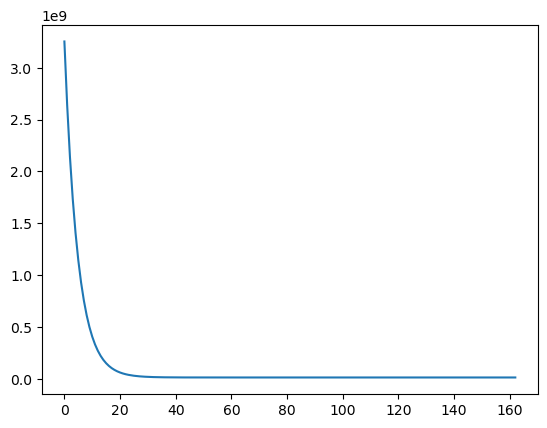

In [37]:
plt.plot(loss_history)

model.plt(X_norm,Y)